In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [40]:
df_train = pd.read_csv('aug_train.csv')
df_test = pd.read_csv('aug_test.csv')

In [41]:
df_train.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


<Axes: >

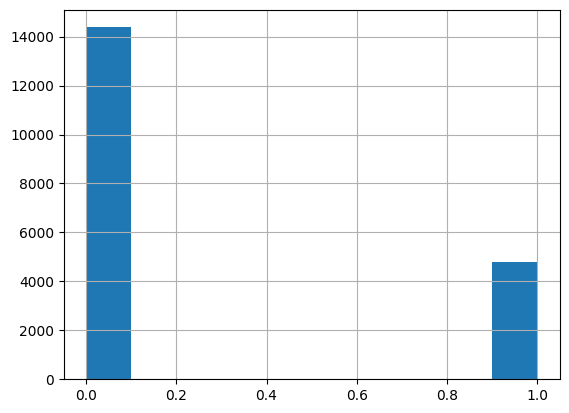

In [42]:
df_train['target'].hist()

In [43]:
print((df_train.shape),(df_test.shape))

(19158, 14) (2129, 13)


In [44]:
def missing_values(df):
    total = df.isnull().sum().sort_values(ascending=False)
    percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    return pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

In [45]:
missing_values(df_train)

,Total,Percent
company_type,6140,0.320493
company_size,5938,0.309949
gender,4508,0.235306
major_discipline,2813,0.146832
education_level,460,0.024011
last_new_job,423,0.022080
enrolled_university,386,0.020148
experience,65,0.003393
enrollee_id,0,0.000000
city,0,0.000000


In [46]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [47]:
missing_values(df_test)

,Total,Percent
company_type,634,0.297792
company_size,622,0.292156
gender,508,0.238610
major_discipline,312,0.146548
education_level,52,0.024425
last_new_job,40,0.018788
enrolled_university,31,0.014561
experience,5,0.002349
enrollee_id,0,0.000000
relevent_experience,0,0.000000


In [48]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             2129 non-null   int64  
 1   city                    2129 non-null   object 
 2   city_development_index  2129 non-null   float64
 3   gender                  1621 non-null   object 
 4   relevent_experience     2129 non-null   object 
 5   enrolled_university     2098 non-null   object 
 6   education_level         2077 non-null   object 
 7   major_discipline        1817 non-null   object 
 8   experience              2124 non-null   object 
 9   company_size            1507 non-null   object 
 10  company_type            1495 non-null   object 
 11  last_new_job            2089 non-null   object 
 12  training_hours          2129 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 216.4+ KB


In [ ]:

def clean_data(df):
    df['experience'] = df['experience'].str.replace('>', '').str.replace('<', '')
    df['experience'] = df['experience'].fillna(0).astype(int)
    df['last_new_job'] = df['last_new_job'].str.replace('>', '').str.replace('<', '')
    df['last_new_job'] = df['last_new_job'].str.replace('never', '0')
    df['last_new_job'] = df['last_new_job'].fillna(0).astype(int)

    return df

df_train = clean_data(df_train)
df_test = clean_data(df_test)

In [50]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,precision_score, recall_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Model: XGB
F1 Score: 0.6235294117647059
Accuracy: 0.7828810020876826
Precision: 0.5476947535771065
Recall: 0.7237394957983193
Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.80      0.85      2880
         1.0       0.55      0.72      0.62       952

    accuracy                           0.78      3832
   macro avg       0.72      0.76      0.74      3832
weighted avg       0.81      0.78      0.79      3832

------------------------------
------------------------------
Train F1_score]: 0.6809891462459439
Test F1_score: 0.6235294117647059


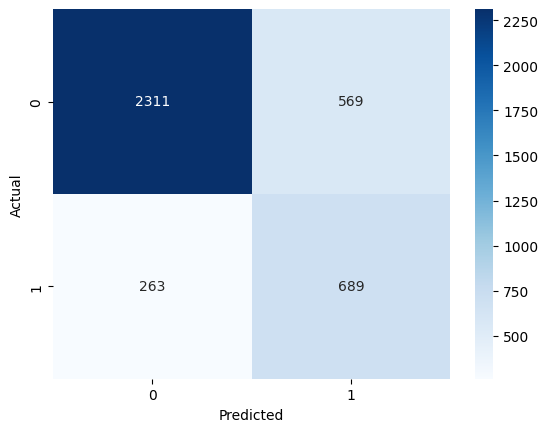

------------------------------
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\simoen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\simoen\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Model: LR
F1 Score: 0.6213760276936391
Accuracy: 0.7716597077244259
Precision: 0.5283296541574687
Recall: 0.7542016806722689
Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.78      0.84      2880
         1.0       0.53      0.75      0.62       952

    accuracy                           0.77      3832
   macro avg       0.72      0.77      0.73      3832
weighted avg       0.81      0.77      0.78      3832

------------------------------
------------------------------
Train F1_score]: 0.6224137931034482
Test F1_score: 0.6213760276936391


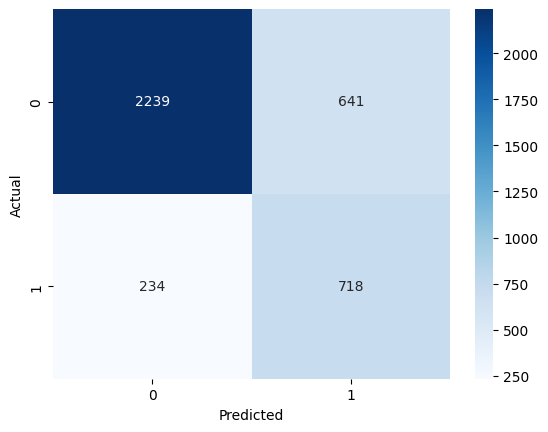

------------------------------
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Model: RF
F1 Score: 0.5426356589147286
Accuracy: 0.784446764091858
Precision: 0.5737704918032787
Recall: 0.5147058823529411
Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.87      0.86      2880
         1.0       0.57      0.51      0.54       952

    accuracy                           0.78      3832
   macro avg       0.71      0.69      0.70      3832
weighted avg       0.78      0.78      0.78      3832

------------------------------
------------------------------
Train F1_score]: 0.7238965862019712
Test F1_score: 0.5426356589147286


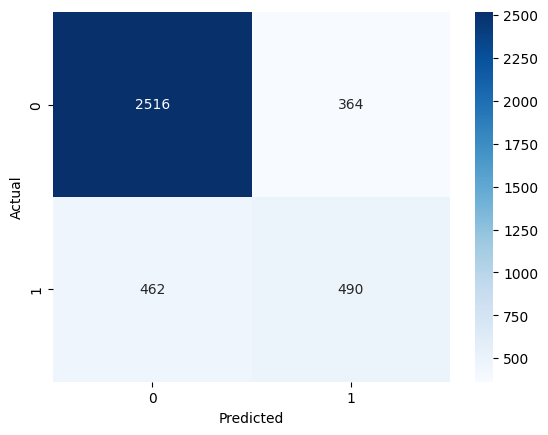

------------------------------


In [51]:
X = df_train.drop(['enrollee_id', 'target'], axis=1)
y = df_train['target']

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models={
    'XGB': XGBClassifier(),
    'LR': LogisticRegression(),
    'RF': RandomForestClassifier()
}
XGB_parameters = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 6],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1],
    'classifier__scale_pos_weight': [3]
}

LR_parameters = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': ['balanced']
}

RF_parameters = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

parameters = {
    'XGB': XGB_parameters,
    'LR': LR_parameters,
    'RF': RF_parameters
}

best_models = {}
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    model_parms= RandomizedSearchCV(estimator=pipe, param_distributions = parameters[name], n_iter=10, cv=5, random_state=42, n_jobs=-1, verbose=1, scoring='f1')
    model_parms.fit(X_train, y_train)
    best_model = model_parms.best_estimator_
    best_models[name] = best_model
    y_pred = best_model.predict(X_test)
    print(f"Model: {name}")
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print('-' * 30)
    train_pred = best_model.predict(X_train)
    test_pred = best_model.predict(X_test)
    print('-' * 30)
    print("Train F1_score]:", f1_score(y_train, train_pred))
    print("Test F1_score:", f1_score(y_test, test_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print("-" * 30)

In [ ]:
df_test_processed = df_test.drop(['enrollee_id'], axis=1)
final_model = best_models['LR'] 
test_pred = final_model.predict(df_test_processed)

submission = pd.DataFrame({
    'enrollee_id': df_test['enrollee_id'],
    'target': test_pred
})

submission.to_csv('submission.csv', index=False)

Submission file created ✅
